In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dhairyajeetsingh/ecommerce-customer-behavior-dataset/ecommerce_customer_churn_dataset.csv


# 1. Introduction

**Dataset Name:** Ecommerce Customer Behavior Dataset.

**Applying Method:** Machine Learning

**Using Model:** Logistic Regression, K-Nearest Neighbors, Support Vector Machine, Random Forest, XGBoost, LightGBM, and CatBoost

**Dataset Link:** /kaggle/input/datasets/dhairyajeetsingh/ecommerce-customer-behavior-dataset

**Missing Values:** yes

**Duplicate Values:** no

**Best Model:** 


# 2. Setup & import libraries

In [11]:
# ─── Install Dependencies ───
!pip install -q xgboost lightgbm catboost
print("Environment ready.")

Environment ready.


In [12]:
# ─── Imports ───
import warnings, time, gc
warnings.filterwarnings("ignore")

import glob, shap
from pathlib import Path

# --- Import Data Analysis & Visualization Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# --- Import Data Splitting, Cross-Validation & Feature Scaling ---
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# --- Import Machine Learning Classification Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# --- Import Classification Evaluation Metrics ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve,
    balanced_accuracy_score, matthews_corrcoef, average_precision_score, precision_recall_curve
)


# ─── Plot Configuration ───
sns.set_style("whitegrid")
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 600, "savefig.bbox": "tight", "font.size": 11})
SEED = 42
np.random.seed(SEED)

print("✅ All libraries loaded!")
print("Environment ready.")

✅ All libraries loaded!
Environment ready.


# 3. Dataset Loading

In [13]:
file_path = "/kaggle/input/datasets/dhairyajeetsingh/ecommerce-customer-behavior-dataset/ecommerce_customer_churn_dataset.csv"

df = pd.read_csv(file_path)
print("✅ Dataset loaded!")

✅ Dataset loaded!


# 4. Explore the Data (EDA)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [15]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [16]:
Target = "Churned"
print("Target ready.")

Target ready.


In [17]:
print(f"Dataset shape : {df.shape}")
print(f"Class balance : {dict(df[Target].value_counts())}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows  : {df.duplicated().sum()}")
print(f"Dtypes        : {dict(df.dtypes.value_counts())}")

Dataset shape : (50000, 25)
Class balance : {0: np.int64(35550), 1: np.int64(14450)}
Missing values: 49081
Duplicate rows  : 0
Dtypes        : {dtype('float64'): np.int64(20), dtype('O'): np.int64(4), dtype('int64'): np.int64(1)}


In [18]:
# Create a table containing missing-value information for each column
null_table = pd.DataFrame({
    'Column': df.columns,
    
    # Count the number of missing (NaN/None) values in each column
    'Null Count': df.isna().sum().values,
    
    # Calculate the percentage of missing values in each column
    'Null Percentage (%)': (
        df.isna().sum().values / len(df) * 100
    ).round(2)
})

# Keep only the columns that contain at least one null value
null_table = null_table[null_table['Null Count'] > 0]

# Sort from highest to lowest number of null values
null_table = null_table.sort_values(
    by='Null Count',
    ascending=False
).reset_index(drop=True)

# Display the final table
display(null_table)

,Column,Null Count,Null Percentage (%)
0,Social_Media_Engagement_Score,6000,12.00
1,Credit_Balance,5500,11.00
2,Mobile_App_Usage,5000,10.00
3,Returns_Rate,4491,8.98
4,Wishlist_Items,4000,8.00
5,Discount_Usage_Rate,3500,7.00
6,Product_Reviews_Written,3500,7.00
7,Session_Duration_Avg,3399,6.80
8,Pages_Per_Session,3000,6.00
9,Days_Since_Last_Purchase,3000,6.00


In [19]:
# --- Handle Missing Values ---

# Numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill numeric missing values with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check remaining missing values
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [20]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,37.812800,2.984009,11.624660,27.602240,8.717542,57.079973,4.274520,13.111576,123.117330,29.265300,...,6.565861,20.875388,5.679540,2.793580,29.152730,19.294446,2.33618,1440.626292,1958.507600,0.289000
std,11.535688,2.059105,7.810657,10.497234,3.663996,16.282723,3.060573,7.017312,175.569714,28.866043,...,5.872081,13.890225,2.671844,2.256482,19.308632,8.938875,1.08465,907.249443,1155.938248,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000
25%,30.000000,1.400000,6.000000,20.200000,6.200000,46.400000,2.000000,8.000000,87.050000,9.000000,...,3.100000,10.500000,4.000000,1.000000,15.300000,13.200000,2.00000,789.817500,1164.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.00000,1243.415000,1896.000000,0.000000
75%,45.000000,4.000000,17.000000,34.000000,11.000000,68.700000,6.000000,17.000000,144.440000,39.000000,...,8.600000,29.700000,7.000000,4.000000,40.700000,24.600000,3.00000,1874.000000,2664.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.00000,8987.240000,7197.000000,1.000000


In [21]:
# --- Encode All Categorical Columns ---

categorical_cols = df.select_dtypes(include="object").columns

encoder = OrdinalEncoder()

df[categorical_cols] = encoder.fit_transform(
    df[categorical_cols]
)

print(categorical_cols)
df.head()

Index(['Gender', 'Country', 'City', 'Signup_Quarter'], dtype='object')


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,1.0,2.0,21.0,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,0.0
1,36.0,1.0,6.0,20.0,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,27.6,23.3,3.0,1067.47,3028.0,0,3.0
2,45.0,0.0,1.0,38.0,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,27.6,8.8,2.0,1289.75,2317.0,0,3.0
3,56.0,0.0,7.0,27.0,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,0.0
4,35.0,1.0,4.0,9.0,3.1,29.0,51.4,8.4,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,3.0


In [22]:
df.describe()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,37.812800,0.516420,4.45008,19.022680,2.984009,11.624660,27.602240,8.717542,57.079973,4.274520,...,20.875388,5.679540,2.793580,29.152730,19.294446,2.33618,1440.626292,1958.507600,0.289000,1.500820
std,11.535688,0.535925,2.52657,10.876763,2.059105,7.810657,10.497234,3.663996,16.282723,3.060573,...,13.890225,2.671844,2.256482,19.308632,8.938875,1.08465,907.249443,1155.938248,0.453302,1.116631
min,5.000000,0.000000,0.00000,0.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,2.00000,10.000000,1.400000,6.000000,20.200000,6.200000,46.400000,2.000000,...,10.500000,4.000000,1.000000,15.300000,13.200000,2.00000,789.817500,1164.000000,0.000000,1.000000
50%,38.000000,0.000000,5.00000,18.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,...,19.700000,5.000000,2.000000,27.600000,18.600000,2.00000,1243.415000,1896.000000,0.000000,2.000000
75%,45.000000,1.000000,7.00000,28.000000,4.000000,17.000000,34.000000,11.000000,68.700000,6.000000,...,29.700000,7.000000,4.000000,40.700000,24.600000,3.00000,1874.000000,2664.000000,1.000000,2.000000
max,200.000000,2.000000,7.00000,39.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,...,91.700000,21.000000,21.000000,100.000000,61.900000,5.00000,8987.240000,7197.000000,1.000000,3.000000


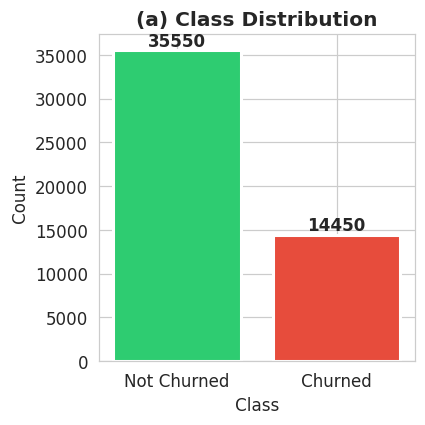

In [23]:
# ─── Exploratory Data Analysis (EDA) ───
num_df = df.select_dtypes(include="number")

fig, ax = plt.subplots(figsize=(4, 4))

# (a) Class Distribution
lbl = df[Target].value_counts().sort_index()

bars = ax.bar(
    ["Not Churned", "Churned"],
    lbl.values,
    color=["#2ecc71", "#e74c3c"],
    edgecolor="white",
    linewidth=2
)

ax.set_title("(a) Class Distribution", fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

# Add count numbers on top of bars
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "(a) Class Distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

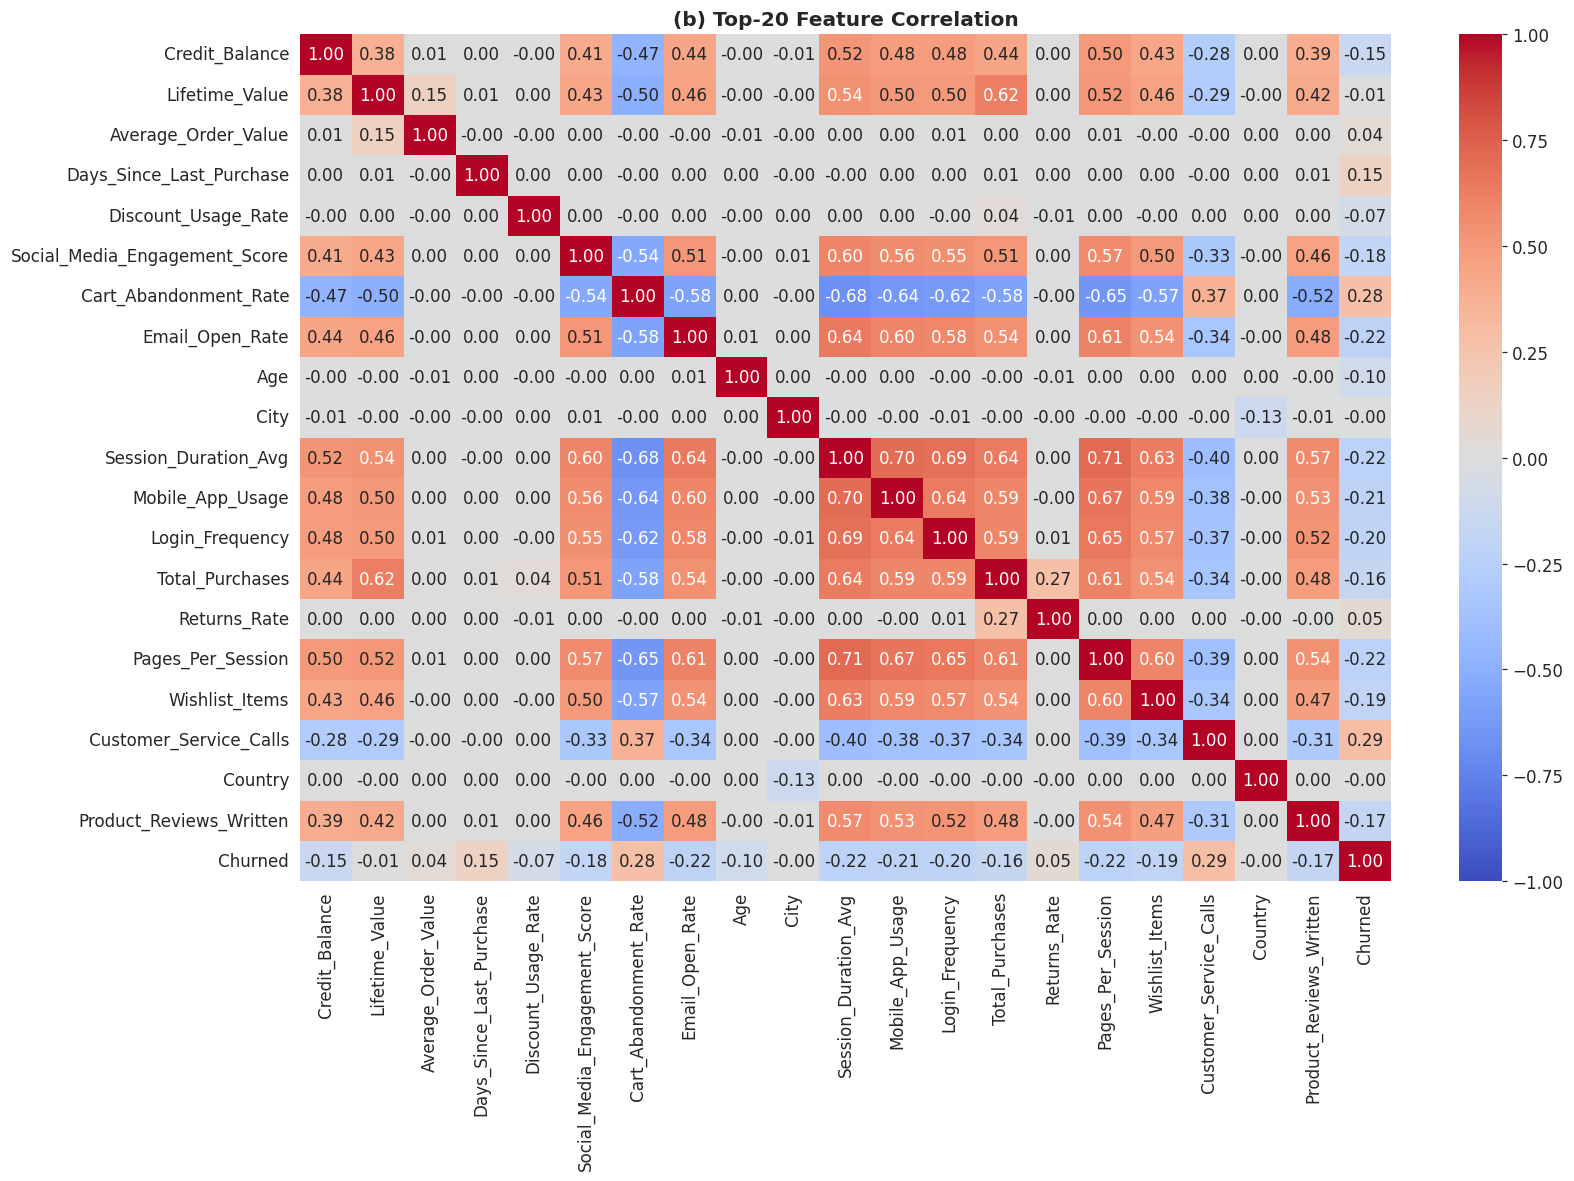

In [24]:
# ─── Exploratory Data Analysis (EDA) ───
num_df = df.select_dtypes(include="number")
fig, ax = plt.subplots(figsize=(16,10))

# (b) Correlation Heatmap (Top-20 variable features)
top_feats = num_df.drop(columns=Target).std().nlargest(20).index.tolist()
corr = num_df[top_feats + [Target]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.2f', ax=ax)
ax.set_title("(b) Top-20 Feature Correlation", fontweight="bold")
# Save the figure
plt.savefig(
    "(b) Top-20 Feature Correlation.png",
    dpi=600,
    bbox_inches="tight"
)

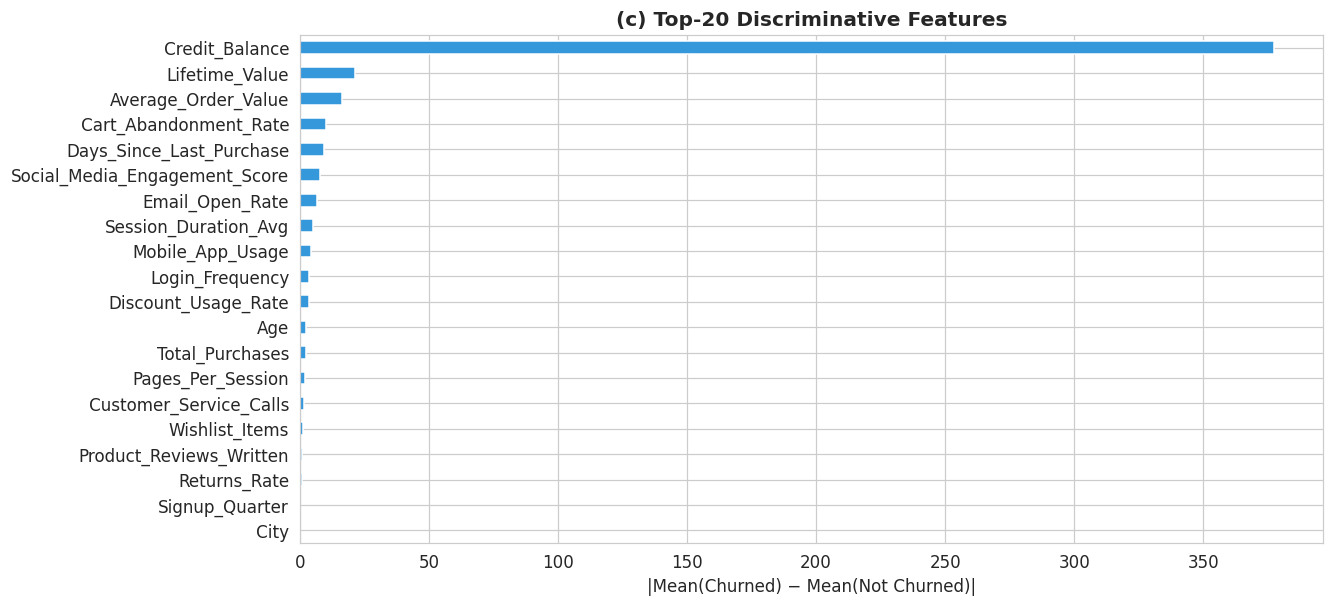

In [25]:
# ─── Exploratory Data Analysis (EDA) ───
num_df = df.select_dtypes(include="number")
fig, ax = plt.subplots(figsize=(12,6))

# (c) Mean Absolute Difference per Feature
grp_mean = num_df.groupby(Target).mean()
mean_diff = (grp_mean.iloc[1] - grp_mean.iloc[0]).abs().sort_values(ascending=False).head(20)
mean_diff.sort_values().plot.barh(ax=ax, color="#3498db", edgecolor="white")
ax.set_title("(c) Top-20 Discriminative Features", fontweight="bold")
ax.set_xlabel("|Mean(Churned) − Mean(Not Churned)|")
# Save the figure
plt.savefig(
    "(c) Top-20 Discriminative Features.png",
    dpi=600,
    bbox_inches="tight"
)

# 5. Preprocessing Pipeline

In [26]:
# ─── Feature Engineering & Selection ───
X = df.drop(columns=Target).select_dtypes(include="number")
y = df[Target]

n_initial = X.shape[1]

# Step 1: Remove zero-variance features
zero_var = X.columns[X.std() == 0].tolist()
X = X.drop(columns=zero_var)

# Step 2: Remove highly correlated features (|r| > 0.95)
corr_mat = X.corr().abs()
upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
redundant = [c for c in upper_tri.columns if any(upper_tri[c] > 0.95)]
X = X.drop(columns=redundant)

print(f"Features: {n_initial} → {X.shape[1]} "
      f"(removed {len(zero_var)} zero-var, {len(redundant)} redundant)")
pd.Series({"features": X.shape[1], "samples": len(X), "default_rate": round(y.mean(), 4)})

Features: 24 → 24 (removed 0 zero-var, 0 redundant)


features           24.000
samples         50000.000
default_rate        0.289
dtype: float64

In [27]:
# Step 3: Stratified Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# Step 4: Z-score Standardization
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")

Train: (40000, 24), Test: (10000, 24)


# 6. Model Training & Evaluation

In [28]:
# ─── Evaluation Function ───
def evaluate(model, Xtr, Xte, ytr, yte, name):
    """Train model, predict, and return metric dictionary."""
    t0 = time.time()
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else pred
    elapsed = time.time() - t0
    return {
        "Model": name,
        "Accuracy":  round(accuracy_score(yte, pred), 4),
        "Precision": round(precision_score(yte, pred), 4),
        "Recall":    round(recall_score(yte, pred), 4),
        "F1-Score":  round(f1_score(yte, pred), 4),
        "AUC-ROC":   round(roc_auc_score(yte, prob), 4),
        "Balanced Acc.": round(balanced_accuracy_score(yte, pred), 4),
        "MCC": round(matthews_corrcoef(yte, pred), 4),
        "PR-AUC": round(average_precision_score(yte, prob), 4),
        "Time (s)": round(elapsed, 2)
    }

# ─── Define Classifiers ───
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1, random_state=SEED),
    "KNN (k=7)":           KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    "SVM (RBF)":           SVC(kernel="rbf", C=10, gamma="scale", probability=True),
    "Random Forest":       RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
    "XGBoost":             xgb.XGBClassifier(n_estimators=300, tree_method="hist",
                                             n_jobs=-1, random_state=SEED, eval_metric="logloss"),
    "LightGBM":            lgb.LGBMClassifier(n_estimators=300, n_jobs=-1, random_state=SEED, verbose=-1),
    "CatBoost":            cb.CatBoostClassifier(iterations=300, verbose=0, random_state=SEED),
}

# ─── SVM Subsampling (scalability) ───
# SVM_SAMPLE = min(50_000, len(X_train_s))
# svm_idx = np.random.choice(len(X_train_s), size=SVM_SAMPLE, replace=False)

# ─── Train & Evaluate All Models ───
results = []
for name, mdl in models.items():
        # Use all training rows for all models
    Xtr = X_train_s
    ytr = y_train
    # Xtr = X_train_s[svm_idx] if "SVM" in name else X_train_s
    # ytr = y_train.iloc[svm_idx] if "SVM" in name else y_train
    row = evaluate(mdl, Xtr, X_test_s, ytr, y_test, name)
    results.append(row)
    print(f"  ✓ {name:25s} | Acc={row['Accuracy']:.4f}  F1={row['F1-Score']:.4f}  AUC={row['AUC-ROC']:.4f}")

results_df = pd.DataFrame(results).sort_values("AUC-ROC", ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print("TABLE I: Comparative Performance of Classifiers")
print("="*70)
display(results_df.style.background_gradient(
    cmap="YlGn",
    subset=[ "Accuracy","Precision","Recall","F1-Score","AUC-ROC","Balanced Acc.","MCC","PR-AUC"])
    .format(precision=4, subset=[ "Accuracy","Precision","Recall","F1-Score","AUC-ROC","Balanced Acc.","MCC","PR-AUC"]))

  ✓ Logistic Regression       | Acc=0.7757  F1=0.5223  AUC=0.7908
  ✓ KNN (k=7)                 | Acc=0.7987  F1=0.5465  AUC=0.8071
  ✓ SVM (RBF)                 | Acc=0.8717  F1=0.7597  AUC=0.8951
  ✓ Random Forest             | Acc=0.9177  F1=0.8464  AUC=0.9263
  ✓ XGBoost                   | Acc=0.9147  F1=0.8435  AUC=0.9238
  ✓ LightGBM                  | Acc=0.9222  F1=0.8553  AUC=0.9302
  ✓ CatBoost                  | Acc=0.9244  F1=0.8598  AUC=0.9295

TABLE I: Comparative Performance of Classifiers


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Balanced Acc.,MCC,PR-AUC,Time (s)
0,LightGBM,0.9222,0.9244,0.7958,0.8553,0.9302,0.8847,0.8067,0.9137,1.090000
1,CatBoost,0.9244,0.9261,0.8024,0.8598,0.9295,0.8882,0.8123,0.9122,2.760000
2,Random Forest,0.9177,0.9189,0.7844,0.8464,0.9263,0.8781,0.7953,0.9065,15.340000
3,XGBoost,0.9147,0.8980,0.7952,0.8435,0.9238,0.8792,0.7879,0.9021,1.710000
4,SVM (RBF),0.8717,0.8281,0.7017,0.7597,0.8951,0.8213,0.6773,0.8326,686.320000
5,KNN (k=7),0.7987,0.7831,0.4197,0.5465,0.8071,0.6862,0.4666,0.6469,2.570000
6,Logistic Regression,0.7757,0.6792,0.4242,0.5223,0.7908,0.6714,0.4040,0.6304,1.650000


# 7. Cross-Validation (Best Model)

In [29]:
# ─── 5-Fold Stratified Cross-Validation on Best Model ───
best_name = results_df.iloc[0]["Model"]
best_mdl  = models[best_name]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(best_mdl, X_train_s, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"Best Model: {best_name}")
print(f"5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold AUC : {np.round(cv_scores, 4)}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best Model: LightGBM
5-Fold CV AUC: 0.9257 ± 0.0032
Per-fold AUC : [0.931  0.926  0.9266 0.9225 0.9222]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Stored probability keys:
['Logistic Regression', 'KNN (k=7)', 'SVM (RBF)', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']
Best model: LightGBM


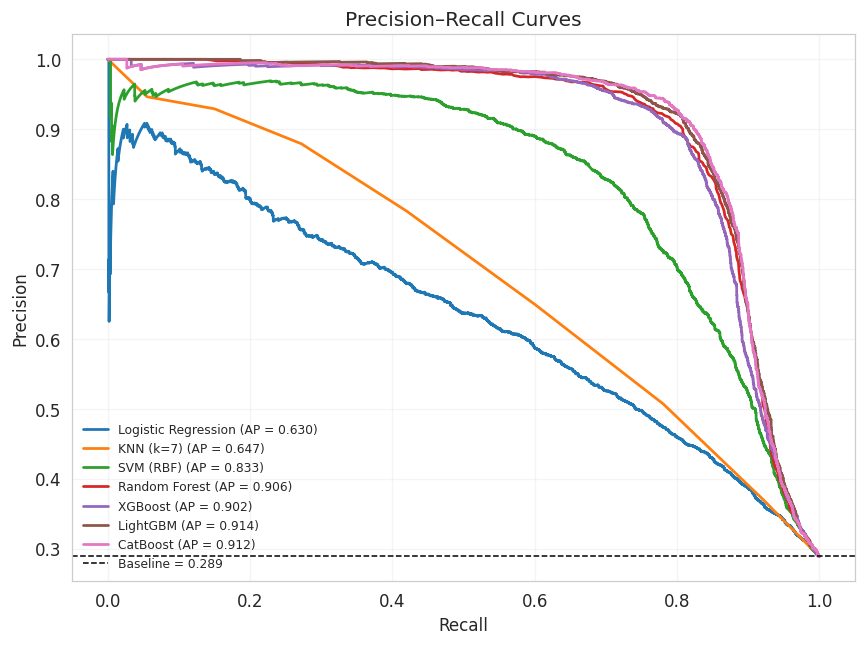

In [46]:
# ─────────────────────────────────────────────
# Store probabilities from trained models
# ─────────────────────────────────────────────

proba = {}

for name, mdl in models.items():

    if hasattr(mdl, "predict_proba"):
        proba[name] = mdl.predict_proba(X_test_s)[:, 1]

    elif hasattr(mdl, "decision_function"):
        proba[name] = mdl.decision_function(X_test_s)

    else:
        proba[name] = mdl.predict(X_test_s).astype(float)


print("Stored probability keys:")
print(list(proba.keys()))


# ─────────────────────────────────────────────
# Best Model
# ─────────────────────────────────────────────

best = results_df.loc[0, "Model"]

print("Best model:", best)


# ─────────────────────────────────────────────
# Precision-Recall Curve
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))


for name, p in proba.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        p
    )

    ap = average_precision_score(
        y_test,
        p
    )

    ax.plot(
        recall,
        precision,
        lw=1.8,
        label=f"{name} (AP = {ap:.3f})"
    )


# ─────────────────────────────────────────────
# No-skill / prevalence baseline
# ─────────────────────────────────────────────

baseline = y_test.mean()

ax.axhline(
    baseline,
    color="k",
    linestyle="--",
    linewidth=1.0,
    label=f"Baseline = {baseline:.3f}"
)


# ─────────────────────────────────────────────
# Labels
# ─────────────────────────────────────────────

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curves")

ax.legend(
    fontsize=8,
    frameon=False
)

ax.grid(
    alpha=0.2
)


fig.tight_layout()


# ─────────────────────────────────────────────
# Save
# ─────────────────────────────────────────────

fig.savefig(
    OUT / "fig_pr_curve.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# 8. Visualizations

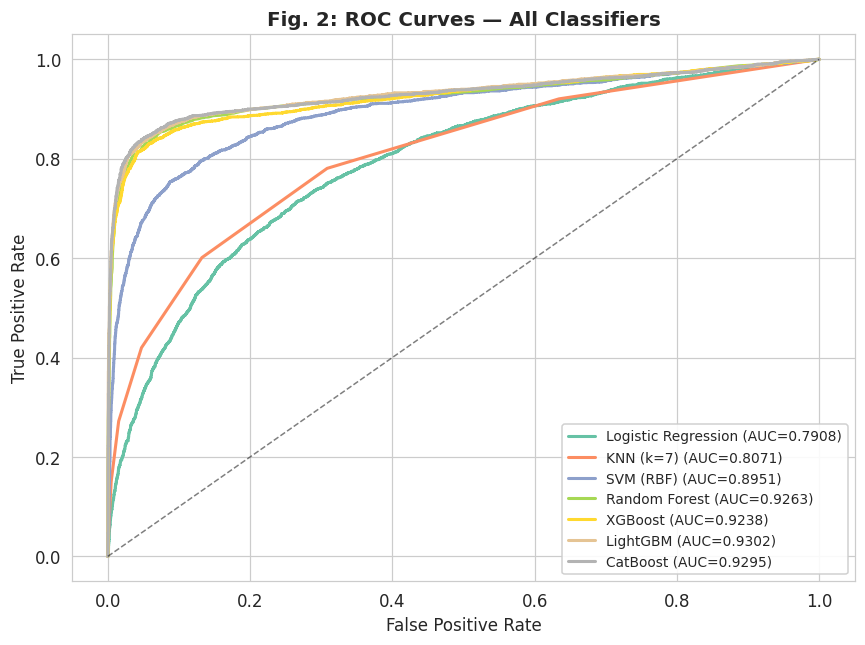

In [30]:
# ─── Fig. 2: ROC Curves for All Classifiers ───
fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.cm.Set2(np.linspace(0, 1, len(models)))

for (name, mdl), clr in zip(models.items(), cmap):
    prob = mdl.predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=clr, lw=2, label=f"{name} (AUC={auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate")
ax.set_title("Fig. 2: ROC Curves — All Classifiers", fontweight="bold", fontsize=13)
ax.legend(fontsize=9, loc="lower right", framealpha=0.9)
plt.tight_layout()
plt.savefig("fig2_roc.png", bbox_inches="tight")
plt.show()

# 9. Confusion Matrix (Best Model)

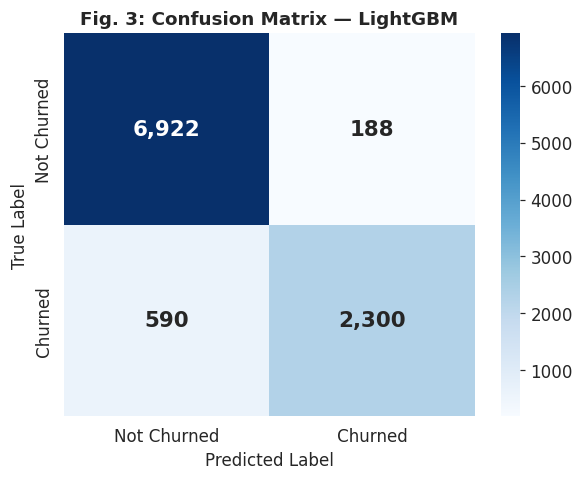


Classification Report — LightGBM
              precision    recall  f1-score   support

 Not Churned       0.92      0.97      0.95      7110
     Churned       0.92      0.80      0.86      2890

    accuracy                           0.92     10000
   macro avg       0.92      0.88      0.90     10000
weighted avg       0.92      0.92      0.92     10000



In [31]:
# ─── Fig. 3: Confusion Matrix (Best Model) ───
cm = confusion_matrix(y_test, best_mdl.predict(X_test_s))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
            xticklabels=["Not Churned", "Churned"],
            yticklabels=["Not Churned", "Churned"],
            annot_kws={"size": 14, "fontweight": "bold"})
ax.set(xlabel="Predicted Label", ylabel="True Label")
ax.set_title(f"Fig. 3: Confusion Matrix — {best_name}", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("fig3_cm.png", bbox_inches="tight")
plt.show()

# Print Classification Report
print(f"\nClassification Report — {best_name}")
print(classification_report(y_test, best_mdl.predict(X_test_s),
                            target_names=["Not Churned", "Churned"]))

# ─── Fig. 4: Top-10 Feature Importance (Best Model) ───

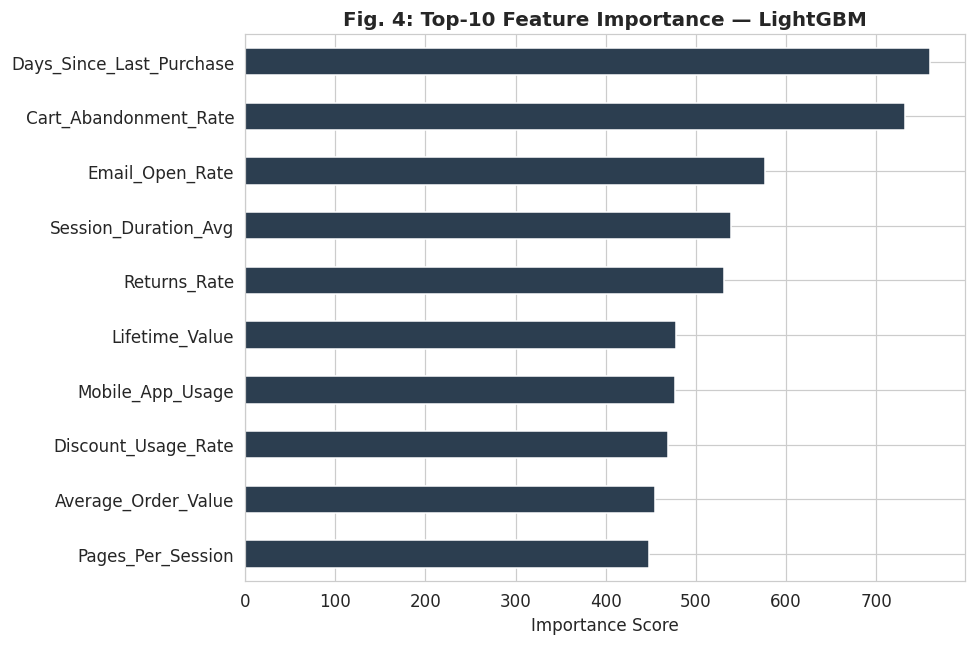

In [32]:
# ─── Fig. 4: Top-10 Feature Importance (Best Model) ───
imp = pd.Series(
    best_mdl.feature_importances_, index=X.columns
).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 6))
imp.sort_values().plot.barh(ax=ax, color="#2c3e50", edgecolor="white")
ax.set_title(f"Fig. 4: Top-10 Feature Importance — {best_name}", fontweight="bold", fontsize=13)
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("fig4_importance.png", bbox_inches="tight")
plt.show()

# 10. Results Summary & Comparison Bar Chart

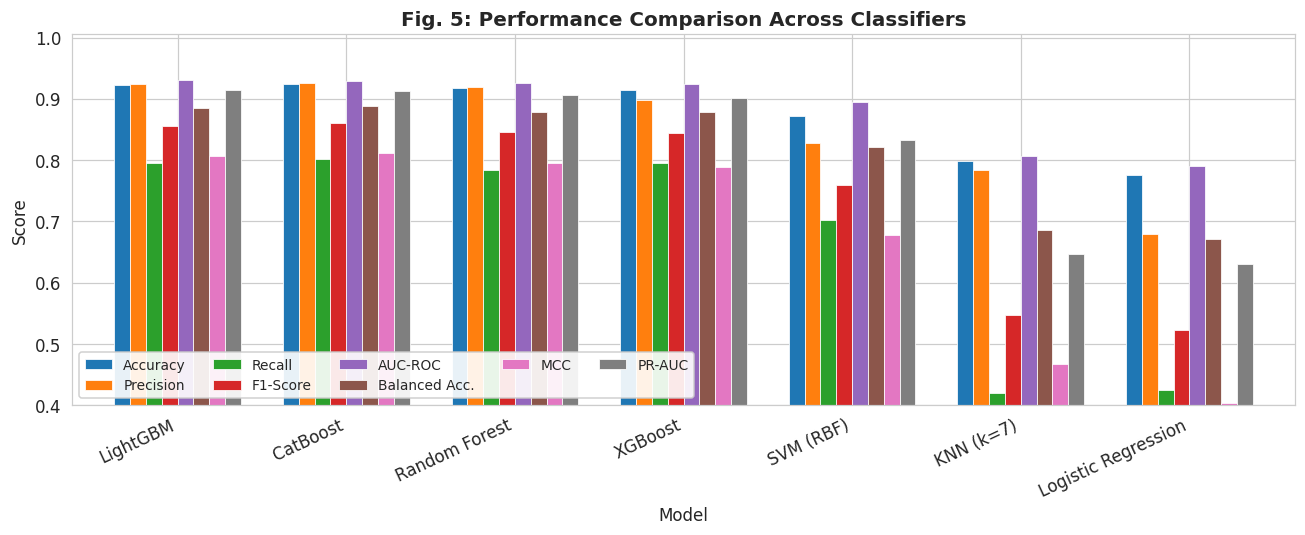

In [47]:
# ─── Fig. 5: Metric Comparison Bar Chart ───
metrics_to_plot = ["Accuracy","Precision","Recall","F1-Score","AUC-ROC","Balanced Acc.","MCC","PR-AUC"]
plot_df = results_df.set_index("Model")[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 5))
plot_df.plot(kind="bar", ax=ax, width=0.75, edgecolor="white", linewidth=0.5)
ax.set_ylim(0.40, 1.005)
ax.set_ylabel("Score")
ax.set_title("Fig. 5: Performance Comparison Across Classifiers", fontweight="bold", fontsize=13)
ax.legend(loc="lower left", fontsize=9, ncol=5, framealpha=0.9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.savefig("fig5_comparison.png", bbox_inches="tight")
plt.show()

# SHAP values

In [59]:
# ─────────────────────────────────────────────
# SHAP Values for Best Model
# ─────────────────────────────────────────────
X_test_s_df = pd.DataFrame(
    X_test_s,
    columns=X_test.columns,
    index=X_test.index
)

best = results_df.loc[0, "Model"]
best_model = models[best]

sample = X_test_s_df.copy()

explainer = shap.TreeExplainer(best_model)
sv = explainer(sample)

print("Best model:", best)
print("Sample shape:", sample.shape)
print("SHAP shape:", sv.values.shape)
print("Feature names:", sv.feature_names)

Best model: LightGBM
Sample shape: (10000, 24)
SHAP shape: (10000, 24)
Feature names: ['Age', 'Gender', 'Country', 'City', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance', 'Signup_Quarter']


# Global explanation

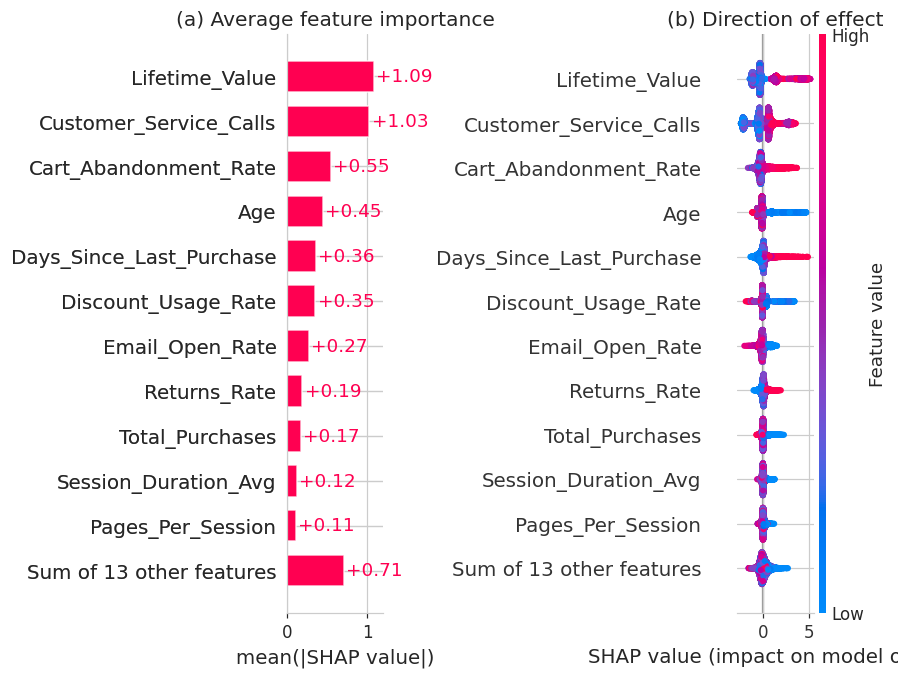

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
plt.sca(ax[0]); shap.plots.bar(sv, max_display=12, show=False)
ax[0].set_title("(a) Average feature importance")
plt.sca(ax[1]); shap.plots.beeswarm(sv, max_display=12, show=False)
ax[1].set_title("(b) Direction of effect")
fig.tight_layout()
fig.savefig(OUT / "fig2_shap_global.png")
plt.show()

# Feature-level explanation

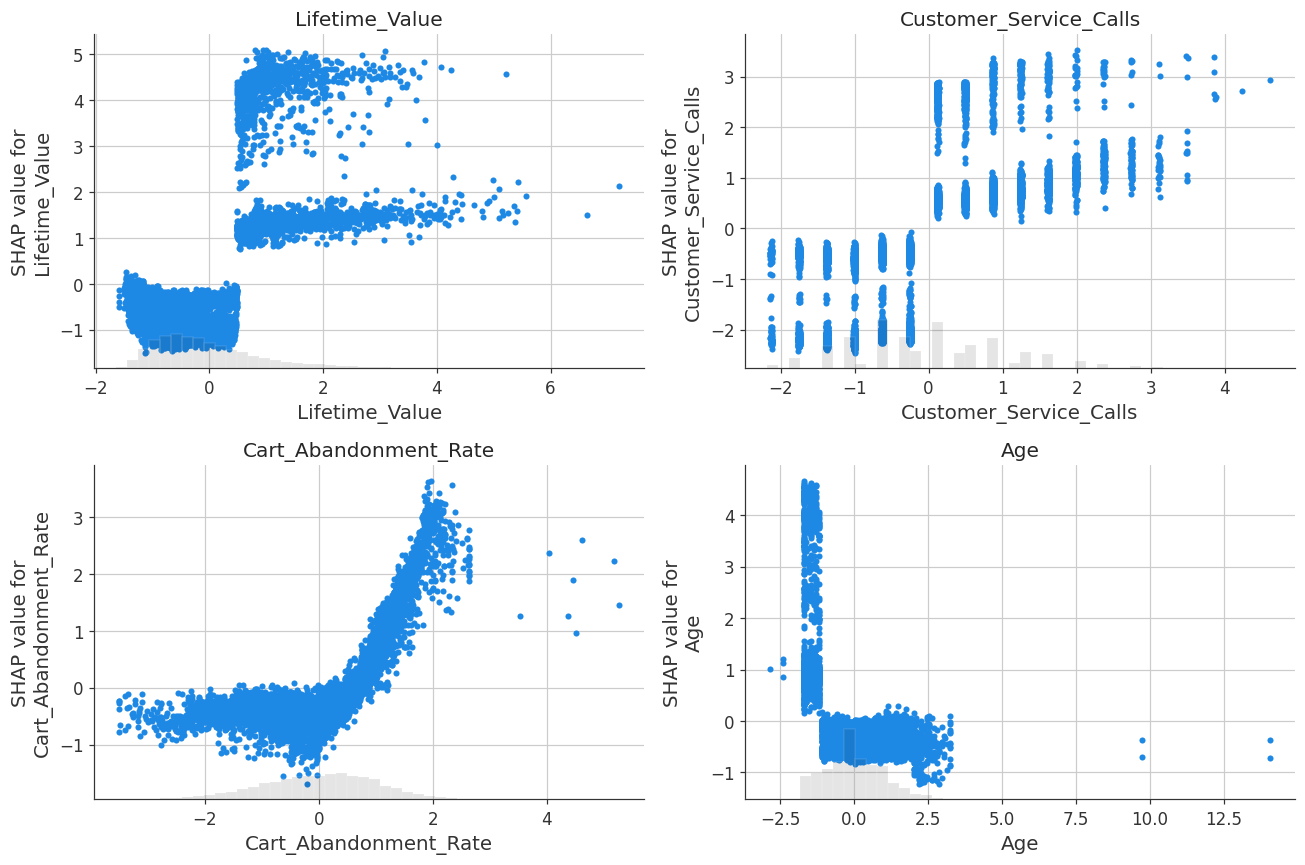

In [61]:
top4 = pd.Series(np.abs(sv.values).mean(0), index=sample.columns).nlargest(4).index
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for a, f in zip(ax.ravel(), top4):
    plt.sca(a); shap.plots.scatter(sv[:, f], ax=a, show=False)
    a.set_title(f)
fig.tight_layout()
fig.savefig(OUT / "fig3_shap_dependence.png")
plt.show()

# Individual explanation

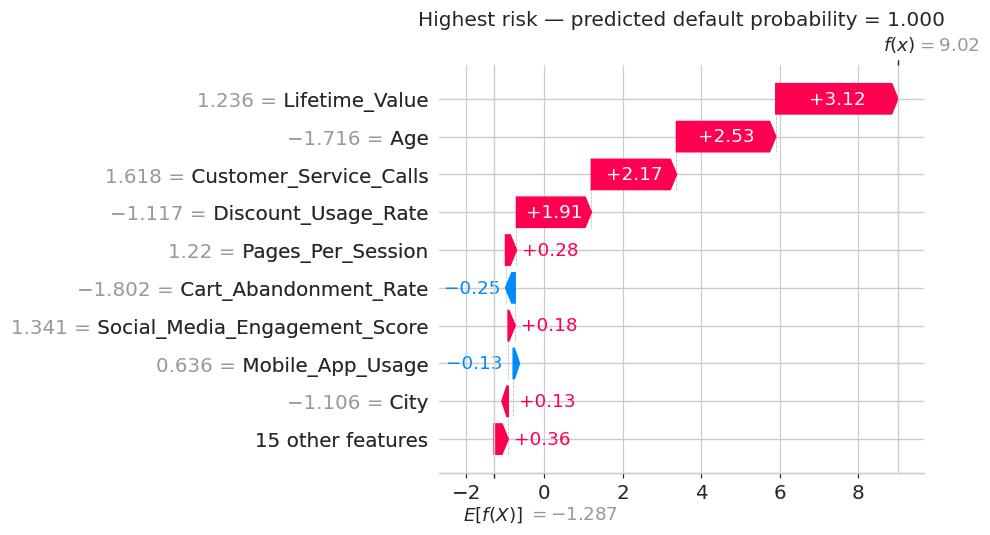

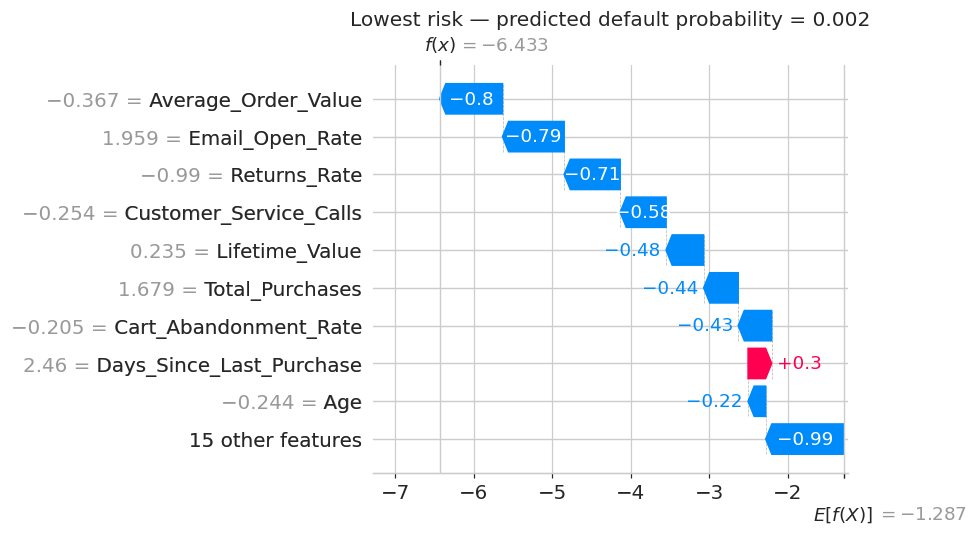

In [63]:
# ─────────────────────────────────────────────
# Local SHAP Explanation:
# Highest-risk and Lowest-risk Applicants
# ─────────────────────────────────────────────

# Predicted probability from the SAME best model
p_sample = best_model.predict_proba(sample)[:, 1]

# Find highest- and lowest-risk observations
cases = {
    "Highest risk": int(np.argmax(p_sample)),
    "Lowest risk": int(np.argmin(p_sample))
}

for label, i in cases.items():

    # Create waterfall plot for one observation
    shap.plots.waterfall(
        sv[i],
        max_display=10,
        show=False
    )

    plt.title(
        f"{label} — predicted default probability = {p_sample[i]:.3f}"
    )

    plt.gcf().set_size_inches(9, 5)

    plt.tight_layout()

    plt.savefig(
        OUT / f"fig4_{label.split()[0].lower()}.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

# Save results

In [64]:
# ─────────────────────────────────────────────
# Save model-performance table
# ─────────────────────────────────────────────

results_df.to_csv(
    OUT / "table1_results.csv",
    index=False
)


# ─────────────────────────────────────────────
# Save global SHAP importance
# mean(|SHAP value|) for each feature
# ─────────────────────────────────────────────

shap_importance = (
    pd.Series(
        np.abs(sv.values).mean(axis=0),
        index=sample.columns,
        name="Mean_abs_SHAP"
    )
    .sort_values(ascending=False)
    .round(6)
)

shap_importance.to_csv(
    OUT / "table2_shap_importance.csv",
    header=True
)


# ─────────────────────────────────────────────
# Show all generated files
# ─────────────────────────────────────────────

sorted(
    p.name
    for p in OUT.iterdir()
)

['fig1_performance.png',
 'fig2_shap_global.png',
 'fig3_shap_dependence.png',
 'fig4_highest.png',
 'fig4_lowest.png',
 'fig_pr_curve.png',
 'table1_results.csv',
 'table2_shap_importance.csv']

In [65]:
from joblib import dump

# Best model
best = results_df.loc[0, "Model"]
best_model = models[best]

print("Best model:", best)

# Save fitted best model
dump(
    best_model,
    OUT / "best_model.joblib"
)

print("Model saved to:", OUT / "best_model.joblib")

Best model: LightGBM
Model saved to: outputs/best_model.joblib
